In [2]:
# install kalau belum
# !pip install pandas requests

import pandas as pd
import requests
from datetime import datetime
import os
from supabase import create_client, Client

url: str = os.environ.get("VITE_SUPABASE_URL")
key: str = os.environ.get("SUPABASE_SERVICE_ROLE_KEY")
supabase: Client = create_client(url, key)

# Get Data

In [3]:
surahs = supabase.table("surahs").select("*").execute()

tadarus_item = supabase.table("tadarus_item").select("""
*,
        tadarus_user(name),
        from_surah:surahs!tadarus_item_from_surah_id_fkey(nama_latin),
        to_surah:surahs!tadarus_item_to_surah_id_fkey(nama_latin)
""").eq("tadarus_id", 1).execute()


In [9]:
df_surahs = pd.DataFrame(surahs.data)
df_tadarus_item = pd.json_normalize(tadarus_item.data)

In [10]:
df_surahs

,id,nama,nama_latin,jumlah_ayat,tempat_turun,arti,deskripsi,audio
0,1,الفاتحة,Al-Fatihah,7,mekah,Pembukaan,Surat <i>Al Faatihah</i> (Pembukaan) yang ditu...,https://santrikoding.com/storage/audio/001.mp3
1,2,البقرة,Al-Baqarah,286,madinah,Sapi,Surat <i>Al Baqarah</i> yang 286 ayat itu turu...,https://santrikoding.com/storage/audio/002.mp3
2,3,اٰل عمران,Ali 'Imran,200,madinah,Keluarga Imran,Surat <i>Ali 'Imran</i> yang terdiri dari 200 ...,https://santrikoding.com/storage/audio/003.mp3
3,4,النساۤء,An-Nisa',176,madinah,Wanita,Surat An Nisaa' yang terdiri dari 176 ayat itu...,https://santrikoding.com/storage/audio/004.mp3
4,5,الماۤئدة,Al-Ma'idah,120,madinah,Hidangan,Surat Al Maa'idah terdiri dari 120 ayat; terma...,https://santrikoding.com/storage/audio/005.mp3
...,...,...,...,...,...,...,...,...
109,110,النصر,An-Nasr,3,madinah,Pertolongan,"Surat An Nashr terdiri atas 3 ayat, termasuk g...",https://santrikoding.com/storage/audio/110.mp3
110,111,اللهب,Al-Lahab,5,mekah,Api Yang Bergejolak,"Surat ini terdiri atas 5 ayat, termasuk golong...",https://santrikoding.com/storage/audio/111.mp3
111,112,الاخلاص,Al-Ikhlas,4,mekah,Ikhlas,"Surat ini terdiri atas 4 ayat, termasuk golong...",https://santrikoding.com/storage/audio/112.mp3
112,113,الفلق,Al-Falaq,5,mekah,Subuh,"Surat ini terdiri atas 5 ayat, termasuk golong...",https://santrikoding.com/storage/audio/113.mp3


In [11]:
df_tadarus_item

,id,created_at,tadarus_id,from_ayah,to_ayah,note,from_surah_id,to_surah_id,tadarus_user.name,from_surah.nama_latin,to_surah.nama_latin
0,5,2026-02-18T20:11:38.159893+00:00,1,31,86,None,2,2,Inna,Al-Baqarah,Al-Baqarah
1,6,2026-02-18T20:12:02.425554+00:00,1,87,150,None,2,2,Farhan,Al-Baqarah,Al-Baqarah
2,7,2026-02-18T20:12:20.23536+00:00,1,151,200,None,2,2,Arika,Al-Baqarah,Al-Baqarah
3,8,2026-02-18T20:12:42.125882+00:00,1,201,231,mantapp,2,2,Rendra,Al-Baqarah,Al-Baqarah
4,9,2026-02-18T21:54:48.093401+00:00,1,232,260,None,2,2,Arika,Al-Baqarah,Al-Baqarah
...,...,...,...,...,...,...,...,...,...,...,...
71,71,2026-03-10T19:37:02.543885+00:00,1,65,135,None,20,20,Inna,Taha,Taha
72,84,2026-03-15T19:20:05.849793+00:00,1,1,55,None,53,54,Puthut,An-Najm,Al-Qamar
73,87,2026-03-15T21:12:36.463829+00:00,1,1,52,None,68,69,Arika,Al-Qalam,Al-Haqqah
74,88,2026-03-16T03:24:25.392063+00:00,1,1,6,None,70,114,Inna,Al-Ma'arij,An-Nas


# Analytics


In [13]:
def count_ayah(surah_map, from_surah, from_ayah, to_surah, to_ayah):
    # case 1: surah sama
    if from_surah == to_surah:
        return to_ayah - from_ayah + 1

    total = 0

    # surah awal
    total += surah_map[from_surah] - from_ayah + 1

    # surah tengah
    for s in range(from_surah + 1, to_surah):
        total += surah_map[s]

    # surah akhir
    total += to_ayah

    return total

surah_map = df_surahs.set_index("id")["jumlah_ayat"].to_dict()

In [14]:
# hitung jumlah ayat
df_tadarus_item["total_ayah"] = df_tadarus_item.apply(
    lambda row: count_ayah(
        surah_map,
        row["from_surah_id"],
        row["from_ayah"],
        row["to_surah_id"],
        row["to_ayah"]
    ),
    axis=1
)


In [16]:
df_tadarus_item["created_at"] = pd.to_datetime(df_tadarus_item["created_at"])

In [18]:
df_tadarus_item["date"] = df_tadarus_item["created_at"].dt.date
df_tadarus_item["hour"] = df_tadarus_item["created_at"].dt.hour

In [19]:
df_tadarus_item

,id,created_at,tadarus_id,from_ayah,to_ayah,note,from_surah_id,to_surah_id,tadarus_user.name,from_surah.nama_latin,to_surah.nama_latin,total_ayah,date,hour
0,5,2026-02-18 20:11:38.159893+00:00,1,31,86,None,2,2,Inna,Al-Baqarah,Al-Baqarah,56,2026-02-18,20
1,6,2026-02-18 20:12:02.425554+00:00,1,87,150,None,2,2,Farhan,Al-Baqarah,Al-Baqarah,64,2026-02-18,20
2,7,2026-02-18 20:12:20.235360+00:00,1,151,200,None,2,2,Arika,Al-Baqarah,Al-Baqarah,50,2026-02-18,20
3,8,2026-02-18 20:12:42.125882+00:00,1,201,231,mantapp,2,2,Rendra,Al-Baqarah,Al-Baqarah,31,2026-02-18,20
4,9,2026-02-18 21:54:48.093401+00:00,1,232,260,None,2,2,Arika,Al-Baqarah,Al-Baqarah,29,2026-02-18,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,71,2026-03-10 19:37:02.543885+00:00,1,65,135,None,20,20,Inna,Taha,Taha,71,2026-03-10,19
72,84,2026-03-15 19:20:05.849793+00:00,1,1,55,None,53,54,Puthut,An-Najm,Al-Qamar,117,2026-03-15,19
73,87,2026-03-15 21:12:36.463829+00:00,1,1,52,None,68,69,Arika,Al-Qalam,Al-Haqqah,104,2026-03-15,21
74,88,2026-03-16 03:24:25.392063+00:00,1,1,6,None,70,114,Inna,Al-Ma'arij,An-Nas,861,2026-03-16,3


In [20]:
df_tadarus_item.groupby("date").size()

date
2026-02-18    8
2026-02-19    3
2026-02-20    2
2026-02-21    5
2026-02-22    4
2026-02-23    1
2026-02-24    4
2026-02-25    2
2026-02-26    4
2026-02-27    2
2026-02-28    1
2026-03-01    1
2026-03-02    1
2026-03-03    1
2026-03-04    2
2026-03-05    3
2026-03-06    2
2026-03-07    4
2026-03-08    3
2026-03-09    3
2026-03-10    3
2026-03-11    1
2026-03-12    2
2026-03-14    4
2026-03-15    9
2026-03-16    1
dtype: int64

## OVERALL SUMMARY


In [24]:
total_ayah = df_tadarus_item["total_ayah"].sum()

total_surah = len(df_surahs)

total_users = df_tadarus_item["tadarus_user.name"].nunique()

total_sessions = len(df_tadarus_item)

total_days_active = df_tadarus_item["date"].nunique()

In [27]:
print("=== 📊 Ramadhan Summary ===")
print(f"📖 Total ayat dibaca      : {total_ayah:,}")
print(f"📚 Total surah disentuh   : {total_surah}")
print(f"👥 Total peserta          : {total_users}")
print(f"🔁 Total session          : {total_sessions}")
print(f"🗓️ Hari aktif            : {total_days_active}")
print()
print(
    f"Ramadhan ini kalian membaca {total_ayah:,} ayat "
    f"dalam {total_sessions} sesi bersama {total_users} orang "
    f"selama {total_days_active} hari aktif."
)

=== 📊 Ramadhan Summary ===
📖 Total ayat dibaca      : 6,375
📚 Total surah disentuh   : 114
👥 Total peserta          : 8
🔁 Total session          : 76
🗓️ Hari aktif            : 26

Ramadhan ini kalian membaca 6,375 ayat dalam 76 sesi bersama 8 orang selama 26 hari aktif.


## LEADERBOARD

In [31]:
top_reader = (
    df_tadarus_item
    .groupby("tadarus_user.name")["total_ayah"]
    .sum()
    .sort_values(ascending=False)
)

top_reader.head(10)

tadarus_user.name
Inna      1968
Ghozi     1211
Arika      853
Rendra     753
Farhan     509
Puthut     433
Reni       423
Hilal      225
Name: total_ayah, dtype: int64

In [32]:
most_sessions = (
    df_tadarus_item
    .groupby("tadarus_user.name")
    .size()
    .sort_values(ascending=False)
)

most_sessions.head(10)

tadarus_user.name
Arika     18
Inna      18
Rendra    14
Reni       9
Ghozi      5
Puthut     5
Hilal      4
Farhan     3
dtype: int64

In [38]:
longest_sessions = df_tadarus_item.sort_values(
    by="total_ayah",
    ascending=False
)

longest_sessions.head(10)

,id,created_at,tadarus_id,from_ayah,to_ayah,note,from_surah_id,to_surah_id,tadarus_user.name,from_surah.nama_latin,to_surah.nama_latin,total_ayah,date,hour
74,88,2026-03-16 03:24:25.392063+00:00,1,1,6,None,70,114,Inna,Al-Ma'arij,An-Nas,861,2026-03-16,3
63,79,2026-03-15 18:33:08.965218+00:00,1,31,88,None,32,38,Ghozi,As-Sajdah,Sad,525,2026-03-15,18
53,75,2026-03-14 15:52:12.334040+00:00,1,1,93,None,24,27,Ghozi,An-Nur,An-Naml,461,2026-03-14,15
57,83,2026-03-15 18:59:28.713168+00:00,1,1,49,None,44,52,Farhan,Ad-Dukhan,At-Tur,370,2026-03-15,18
58,85,2026-03-15 19:22:00.638070+00:00,1,1,69,None,55,57,Inna,Ar-Rahman,Al-Hadid,243,2026-03-15,19
75,82,2026-03-15 18:38:45.994815+00:00,1,1,89,Iktikaf ber 4,41,43,Rendra,Fussilat,Az-Zukhruf,196,2026-03-15,18
59,86,2026-03-15 20:05:18.725894+00:00,1,1,30,None,58,67,Puthut,Al-Mujadalah,Al-Mulk,167,2026-03-15,20
60,76,2026-03-14 16:58:42.881312+00:00,1,1,69,None,28,29,Ghozi,Al-Qasas,Al-'Ankabut,157,2026-03-14,16
52,74,2026-03-12 22:29:38.830382+00:00,1,1,118,None,23,23,Hilal,Al-Mu'minun,Al-Mu'minun,118,2026-03-12,22
72,84,2026-03-15 19:20:05.849793+00:00,1,1,55,None,53,54,Puthut,An-Najm,Al-Qamar,117,2026-03-15,19


In [46]:
print("=== 🏆 Team Leaderboard ===\n")

print("📖 Top Reader:")
for i in range(3):
    user = top_reader.index[i]
    value = top_reader.iloc[i]
    print(f"{i+1}. {user} ({value:,} ayat)")

print("\n🔁 Most Sessions:")
for i in range(3):
    user = most_sessions.index[i]
    value = most_sessions.iloc[i]
    print(f"{i+1}. {user} ({value} sesi)")

print("\n⚡ Longest Session:")
for i in range(3):
    row = longest_sessions.iloc[i]
    user = row["tadarus_user.name"]
    value = row["total_ayah"]
    date = row["date"]
    print(f"{i+1}. {user} ({value} ayat) - {date}")

=== 🏆 Team Leaderboard ===

📖 Top Reader:
1. Inna (1,968 ayat)
2. Ghozi (1,211 ayat)
3. Arika (853 ayat)

🔁 Most Sessions:
1. Arika (18 sesi)
2. Inna (18 sesi)
3. Rendra (14 sesi)

⚡ Longest Session:
1. Inna (861 ayat) - 2026-03-16
2. Ghozi (525 ayat) - 2026-03-15
3. Ghozi (461 ayat) - 2026-03-14


## BEST DAY

In [40]:
best_day_ayah = (
    df_tadarus_item
    .groupby("date")["total_ayah"]
    .sum()
    .sort_values(ascending=False)
)

best_day_ayah_date = best_day_ayah.idxmax()
best_day_ayah_value = best_day_ayah.max()

best_day_sessions = (
    df_tadarus_item
    .groupby("date")
    .size()
    .sort_values(ascending=False)
)

best_day_sessions_date = best_day_sessions.idxmax()
best_day_sessions_value = best_day_sessions.max()


In [42]:
print("=== 📅 Best Day ===")
print(f"📖 Most Ayah     : {best_day_ayah_date} ({best_day_ayah_value:,} ayat)")
print(f"🔁 Most Sessions : {best_day_sessions_date} ({best_day_sessions_value} sesi)")
print()
print(
    f"Hari paling produktif adalah {best_day_ayah_date}, "
    f"dengan {best_day_ayah_value:,} ayat dibaca 🚀"
)

=== 📅 Best Day ===
📖 Most Ayah     : 2026-03-15 (1,882 ayat)
🔁 Most Sessions : 2026-03-15 (9 sesi)

Hari paling produktif adalah 2026-03-15, dengan 1,882 ayat dibaca 🚀


In [43]:
best_day_ayah.head()

date
2026-03-15    1882
2026-03-16     861
2026-03-14     742
2026-02-18     323
2026-03-07     255
Name: total_ayah, dtype: int64

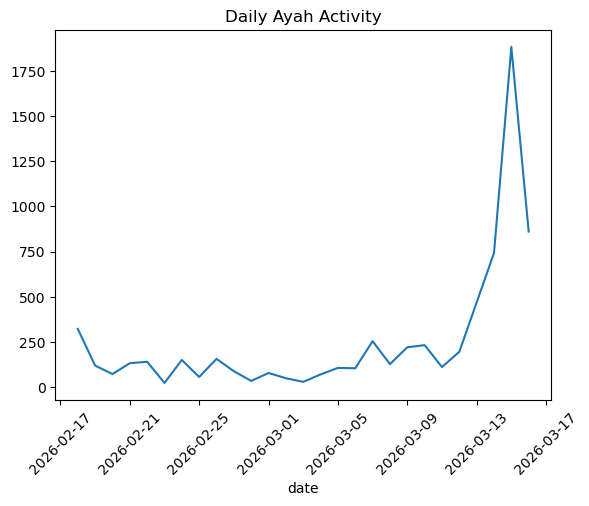

In [44]:
import matplotlib.pyplot as plt

best_day_ayah.sort_index().plot()
plt.title("Daily Ayah Activity")
plt.xticks(rotation=45)
plt.show()

## STREAK

In [49]:
dates = sorted(df_tadarus_item["date"].unique())
longest_streak = 1
current_streak = 1

streak_start = dates[0]
best_start = dates[0]
best_end = dates[0]

for i in range(1, len(dates)):
    diff = (dates[i] - dates[i-1]).days

    if diff == 1:
        current_streak += 1
    else:
        current_streak = 1
        streak_start = dates[i]

    if current_streak > longest_streak:
        longest_streak = current_streak
        best_start = streak_start
        best_end = dates[i]

full_range = pd.date_range(min(dates), max(dates)).date
active_set = set(dates)
longest_break = 0
current_break = 0

break_start = None
best_break_start = None
best_break_end = None

for d in full_range:
    if d not in active_set:
        if current_break == 0:
            break_start = d

        current_break += 1

        if current_break > longest_break:
            longest_break = current_break
            best_break_start = break_start
            best_break_end = d
    else:
        current_break = 0

In [52]:
print("=== 🔥 Longest Active Streak ===")
print(f"{longest_streak} hari")
print(f"{best_start} → {best_end}")
print("\n=== 💤 Longest Break Streak ===")
print(f"{longest_break} hari")
print(f"{best_break_start} → {best_break_end}")
print()
print(
    f"Kalian konsisten selama {longest_streak} hari berturut-turut "
    f"dari {best_start} sampai {best_end} 🔥"
)

=== 🔥 Longest Active Streak ===
23 hari
2026-02-18 → 2026-03-12

=== 💤 Longest Break Streak ===
1 hari
2026-03-13 → 2026-03-13

Kalian konsisten selama 23 hari berturut-turut dari 2026-02-18 sampai 2026-03-12 🔥


In [54]:
user_groups = df_tadarus_item.groupby("tadarus_user.name")
def calculate_streaks(dates):
    dates = sorted(dates)
    
    longest = 1
    current = 1

    start = dates[0]
    best_start = dates[0]
    best_end = dates[0]

    for i in range(1, len(dates)):
        diff = (dates[i] - dates[i-1]).days

        if diff == 1:
            current += 1
        else:
            current = 1
            start = dates[i]

        if current > longest:
            longest = current
            best_start = start
            best_end = dates[i]

    return longest, best_start, best_end

user_streaks = []

for user, group in user_groups:
    dates = group["date"].unique()

    longest, start, end = calculate_streaks(dates)

    user_streaks.append({
        "user": user,
        "longest_streak": longest,
        "start": start,
        "end": end
    })

df_user_streaks = pd.DataFrame(user_streaks).sort_values(
    by="longest_streak", ascending=False
)

df_user_streaks



,user,longest_streak,start,end
4,Inna,6,2026-03-07,2026-03-12
6,Rendra,6,2026-03-05,2026-03-10
0,Arika,4,2026-03-03,2026-03-06
7,Reni,3,2026-02-24,2026-02-26
2,Ghozi,2,2026-02-18,2026-02-19
3,Hilal,2,2026-02-23,2026-02-24
1,Farhan,1,2026-02-18,2026-02-18
5,Puthut,1,2026-02-18,2026-02-18


In [55]:
def calculate_breaks(dates):
    dates = sorted(dates)
    full_range = pd.date_range(min(dates), max(dates)).date
    active_set = set(dates)

    longest = 0
    current = 0

    break_start = None
    best_start = None
    best_end = None

    for d in full_range:
        if d not in active_set:
            if current == 0:
                break_start = d

            current += 1

            if current > longest:
                longest = current
                best_start = break_start
                best_end = d
        else:
            current = 0

    return longest, best_start, best_end

user_breaks = []

for user, group in user_groups:
    dates = group["date"].unique()

    longest, start, end = calculate_breaks(dates)

    user_breaks.append({
        "user": user,
        "longest_break": longest,
        "start": start,
        "end": end
    })

df_user_breaks = pd.DataFrame(user_breaks).sort_values(
    by="longest_break", ascending=False
)

df_user_breaks

,user,longest_break,start,end
1,Farhan,24,2026-02-19,2026-03-14
2,Ghozi,22,2026-02-20,2026-03-13
5,Puthut,21,2026-02-22,2026-03-14
4,Inna,10,2026-02-25,2026-03-06
3,Hilal,9,2026-03-03,2026-03-11
7,Reni,6,2026-02-27,2026-03-04
6,Rendra,5,2026-02-22,2026-02-26
0,Arika,3,2026-02-28,2026-03-02


In [56]:
print("=== 🔥 Longest Streak per User ===")
for i in range(min(3, len(df_user_streaks))):
    row = df_user_streaks.iloc[i]
    print(f"{i+1}. {row['user']} → {row['longest_streak']} hari ({row['start']} → {row['end']})")

print("\n=== 💤 Longest Break per User ===")
for i in range(min(3, len(df_user_breaks))):
    row = df_user_breaks.iloc[i]
    print(f"{i+1}. {row['user']} → {row['longest_break']} hari ({row['start']} → {row['end']})")

=== 🔥 Longest Streak per User ===
1. Inna → 6 hari (2026-03-07 → 2026-03-12)
2. Rendra → 6 hari (2026-03-05 → 2026-03-10)
3. Arika → 4 hari (2026-03-03 → 2026-03-06)

=== 💤 Longest Break per User ===
1. Farhan → 24 hari (2026-02-19 → 2026-03-14)
2. Ghozi → 22 hari (2026-02-20 → 2026-03-13)
3. Puthut → 21 hari (2026-02-22 → 2026-03-14)


## DISTRIBUSI JAM

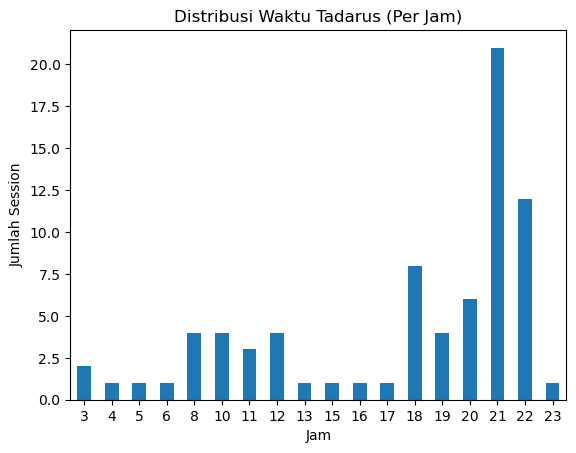

In [57]:
hour_distribution = (
    df_tadarus_item["hour"]
    .value_counts()
    .sort_index()
)

import matplotlib.pyplot as plt

plt.figure()
hour_distribution.plot(kind="bar")

plt.title("Distribusi Waktu Tadarus (Per Jam)")
plt.xlabel("Jam")
plt.ylabel("Jumlah Session")

plt.xticks(rotation=0)
plt.show()

In [63]:
favorite_hour = int(hour_distribution.idxmax())
favorite_count = int(hour_distribution.max())

In [58]:
user_hour_dist = pd.crosstab(
    df_tadarus_item["tadarus_user.name"],
    df_tadarus_item["hour"]
)

user_hour_dist

hour,3,4,5,6,8,10,11,12,13,15,16,17,18,19,20,21,22,23
tadarus_user.name,,,,,,,,,,,,,,,,,,
Arika,1,0,0,0,0,1,0,0,1,0,0,0,2,0,1,12,0,0
Farhan,0,0,0,0,0,0,0,0,0,0,0,0,2,0,1,0,0,0
Ghozi,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,1,1
Hilal,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,2,1,0
Inna,1,0,0,0,0,0,0,2,0,0,0,0,0,2,1,4,8,0
Puthut,0,1,0,0,0,0,0,0,0,0,0,0,1,1,2,0,0,0
Rendra,0,0,1,1,4,3,0,0,0,0,0,0,2,1,1,1,0,0
Reni,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,2,2,0


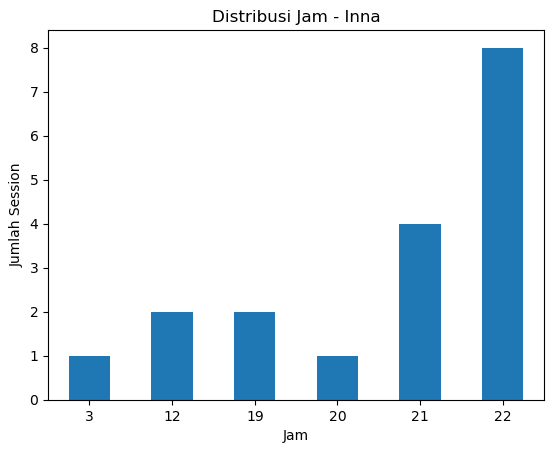

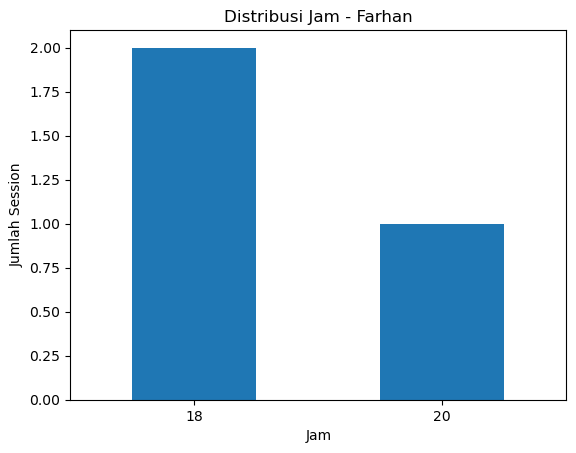

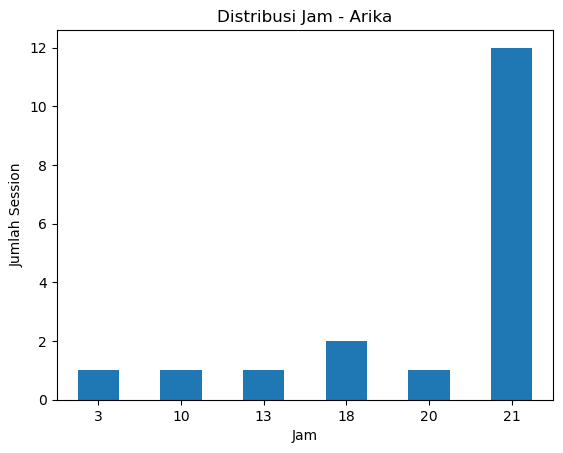

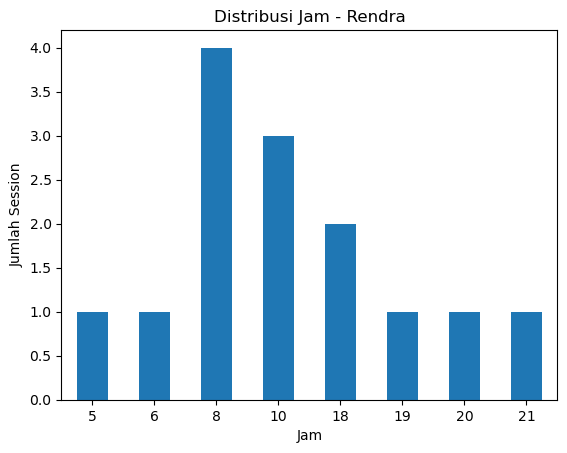

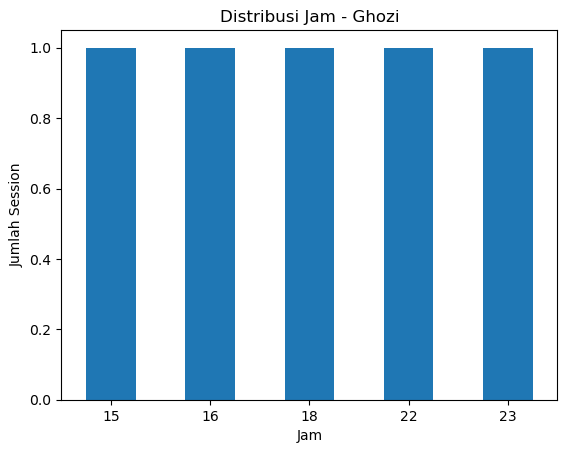

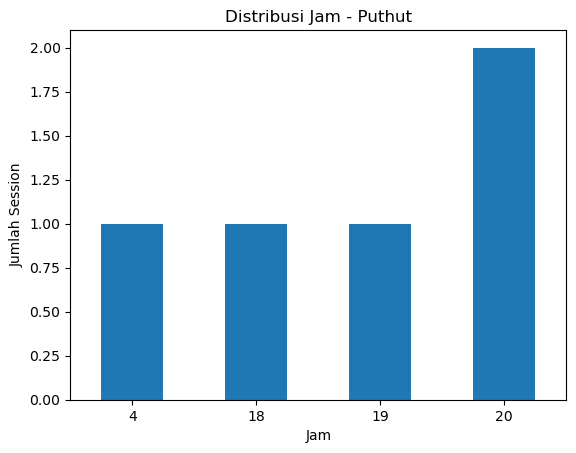

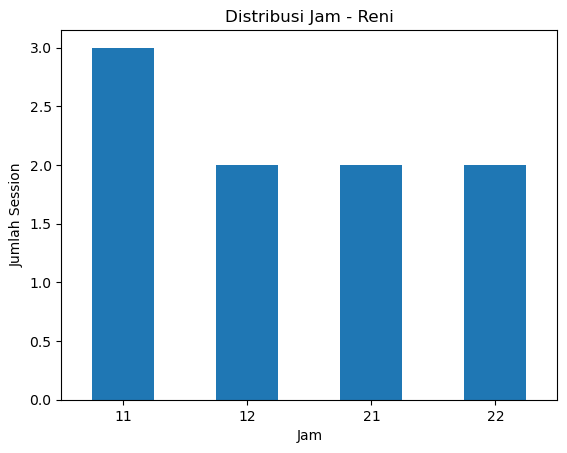

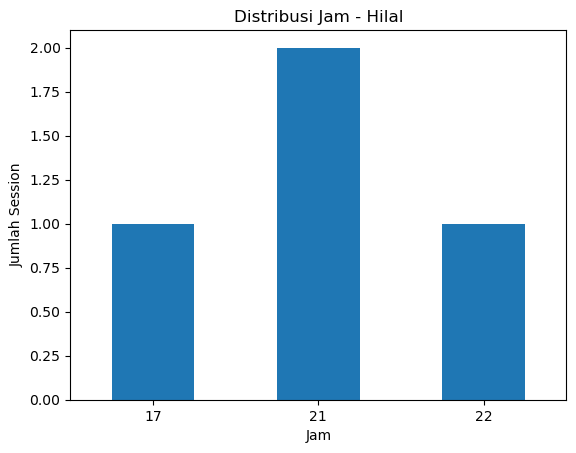

In [59]:
import matplotlib.pyplot as plt

users = df_tadarus_item["tadarus_user.name"].unique()

for user in users:
    plt.figure()

    user_data = df_tadarus_item[
        df_tadarus_item["tadarus_user.name"] == user
    ]

    user_hour = user_data["hour"].value_counts().sort_index()

    user_hour.plot(kind="bar")

    plt.title(f"Distribusi Jam - {user}")
    plt.xlabel("Jam")
    plt.ylabel("Jumlah Session")
    plt.xticks(rotation=0)

    plt.show()

tadarus_user.name
Arika         🌙 Night Owl
Farhan          🌆 Evening
Ghozi        🌤️ Afternoon
Hilal         🌙 Night Owl
Inna          🌙 Night Owl
Puthut        🌙 Night Owl
Rendra    ☀️ Late Morning
Reni      ☀️ Late Morning
Name: hour, dtype: object

## WRAPPED


In [66]:
wrapped = {
    "summary": {},
    "leaderboard": {},
    "best_day": {},
    "streak": {},
    "time_pattern": {},
    "personalities": [],
    "slides": []
}

wrapped["summary"] = {
    "total_ayah": int(total_ayah),
    "total_surah": int(total_surah),
    "total_users": int(total_users),
    "total_sessions": int(total_sessions),
    "total_days_active": int(total_days_active)
}

wrapped["leaderboard"] = {
    "top_reader": [
        {"name": top_reader.index[i], "total_ayah": int(top_reader.iloc[i])}
        for i in range(min(3, len(top_reader)))
    ],
    "most_sessions": [
        {"name": most_sessions.index[i], "total_sessions": int(most_sessions.iloc[i])}
        for i in range(min(3, len(most_sessions)))
    ],
    "longest_session": [
        {
            "name": longest_sessions.iloc[i]["tadarus_user.name"],
            "total_ayah": int(longest_sessions.iloc[i]["total_ayah"]),
        }
        for i in range(min(3, len(longest_sessions)))
    ]
}

wrapped["best_day"] = {
    "most_ayah": {
        "date": str(best_day_ayah_date),
        "total_ayah": int(best_day_ayah_value)
    },
    "most_sessions": {
        "date": str(best_day_sessions_date),
        "total_sessions": int(best_day_sessions_value)
    }
}

timeline = (
    df_tadarus_item
    .groupby("date")["total_ayah"]
    .sum()
    .reset_index()
)

wrapped["timeline"] = [
    {
        "date": str(row["date"]),
        "total_ayah": int(row["total_ayah"])
    }
    for _, row in timeline.iterrows()
]

wrapped["streak"] = {
    "longest_active": {
        "days": int(longest_streak),
        "start": str(best_start),
        "end": str(best_end)
    },
    "longest_break": {
        "days": int(longest_break),
        "start": str(best_break_start),
        "end": str(best_break_end)
    }
}

wrapped["user_streaks"] = [
    {
        "name": row["user"],
        "longest_streak": int(row["longest_streak"]),
        "start": str(row["start"]),
        "end": str(row["end"])
    }
    for _, row in df_user_streaks.iterrows()
]

wrapped["user_breaks"] = [
    {
        "name": row["user"],
        "longest_break": int(row["longest_break"]),
        "start": str(row["start"]),
        "end": str(row["end"])
    }
    for _, row in df_user_breaks.iterrows()
]

wrapped["time_pattern"] = {
    "favorite_hour": int(favorite_hour),
    "favorite_hour_count": int(favorite_count)
}

manual_personalities = [
    {
        "name": "Arika",
        "personality": "🔥 The Consistent One",
        "description": "Si Paling rutin (18 sesi)"
    },
    {
        "name": "Inna",
        "personality": "👑 The Leader",
        "description": "Kontribusi paling banyak (1,968 ayat / 31.5%)"
    },
    {
        "name": "Ghozi",
        "personality": "📖 The Marathon Reader",
        "description": "Sekali baca paling banyak (3 juz solo marathon)"
    },
    {
        "name": "Rendra",
        "personality": "🛠️ The Supporter & Developer",
        "description": "Kasih note paling banyak dan of course he literally build this app"
    },
    {
        "name": "Reni",
        "personality": "🌤️ The Afternoon",
        "description": "Paling sering ngaji siang"
    },
    {
        "name": "Farhan",
        "personality": "🙂 The At Least Ngaji",
        "description": "Paling sedikit (cuma 3 sesi, jirlah)"
    },
    {
        "name": "Puthut",
        "personality": "🚀 The Initiator",
        "description": "Mengawali tadarus paling awal & asbun target 3x khatam"
    },
    {
        "name": "Hilal",
        "personality": "🌪️ The Chaotic",
        "description": "Merusak tatanan tadarus di tengah Ramadhan 😄"
    },
    {
        "name": "Echa",
        "personality": "👻 The Invisible",
        "description": "Gak ngaji sama sekali"
    }
]

wrapped["personalities"] = manual_personalities

In [69]:
wrapped["slides"] = [
    # 1. INTRO
    {
        "type": "intro",
        "data": {
            "text": "🌙 Ramadhan 2026 telah usai...\nTapi perjalanan ini tidak akan terlupakan 🤍\nMari kita lihat kembali jejak tadarus kita tahun ini."
        }
    },

    # 2. SUMMARY
    {
        "type": "summary",
        "data": {
            "text": f"Ramadhan ini, kalian telah membaca {wrapped['summary']['total_ayah']:,} ayat 📖\n"
                    f"Dalam {wrapped['summary']['total_sessions']} sesi, bersama {wrapped['summary']['total_users']} orang hebat 👥\n"
                    f"Dan menjaga konsistensi selama {wrapped['summary']['total_days_active']} hari ✨\n\nMasyaAllah 🤍"
        }
    },

    # 3. TOP READER
    {
        "type": "leaderboard_top_reader",
        "data": {
            "headline": f"👑 {wrapped['leaderboard']['top_reader'][0]['name']} menjadi Top Reader tahun ini",
            "subtext": f"Dengan total {wrapped['leaderboard']['top_reader'][0]['total_ayah']:,} ayat dibaca\nKontribusi yang luar biasa untuk tim 🔥",
            "top3": wrapped["leaderboard"]["top_reader"]
        }
    },

    # 4. MOST SESSION
    {
        "type": "leaderboard_sessions",
        "data": {
            "headline": f"🔁 {wrapped['leaderboard']['most_sessions'][0]['name']} paling sering hadir",
            "subtext": f"Dengan {wrapped['leaderboard']['most_sessions'][0]['total_sessions']} sesi tadarus\nSelalu ada di setiap kesempatan 🤍",
            "top3": wrapped["leaderboard"]["most_sessions"]
        }
    },

    # 5. LONGEST SESSION
    {
        "type": "leaderboard_longest",
        "data": {
            "headline": f"📖 {wrapped['leaderboard']['longest_session'][0]['name']} pernah membaca {wrapped['leaderboard']['longest_session'][0]['total_ayah']} ayat",
            "subtext": "Sebuah effort yang tidak biasa 👏",
            "top3": wrapped["leaderboard"]["longest_session"]
        }
    },

    # 6. BEST DAY
    {
        "type": "best_day",
        "data": {
            "text": f"📅 Hari paling produktif jatuh pada {wrapped['best_day']['most_ayah']['date']}\n"
                    f"Sebanyak {wrapped['best_day']['most_ayah']['total_ayah']:,} ayat dibaca dalam satu hari 🚀\n"
                    f"Hari itu... semua sedang on fire 🔥"
        }
    },

    # 7. TIMELINE
    {
        "type": "timeline",
        "data": {
            "timeline": wrapped["timeline"]
        }
    },

    # 8. STREAK
    {
        "type": "streak",
        "data": {
            "text": f"🔥 Kalian pernah konsisten selama {wrapped['streak']['longest_active']['days']} hari berturut-turut\n"
                    f"Dari {wrapped['streak']['longest_active']['start']} sampai {wrapped['streak']['longest_active']['end']}\n"
                    f"Disitulah momentum terbaik terjadi ✨"
        }
    },

    # 9. BREAK
    {
        "type": "break",
        "data": {
            "text": f"💤 Tapi ada juga bolongnya…\n"
                    f"Selama {wrapped['streak']['longest_break']['days']} hari tanpa tadarus\n"
                    f"Dan itu tidak apa-apa,\nkarena kita selalu kembali 🤍"
        }
    },

    # 10. USER STREAK
    {
        "type": "user_streak",
        "data": {
            "list": wrapped["user_streaks"]
        }
    },

    # 11. USER BREAK
    {
        "type": "user_break",
        "data": {
            "list": wrapped["user_breaks"]
        }
    },

    # 12. TIME PATTERN
    {
        "type": "time_pattern",
        "data": {
            "text": f"🌙 Waktu favorit tadarus adalah pukul {wrapped['time_pattern']['favorite_hour']}:00\n"
                    f"Saat dunia mulai sunyi,\nkalian memilih mendekat 🤍"
        }
    },

    # 13. PERSONALITY
    {
        "type": "personality",
        "data": {
            "list": wrapped["personalities"]
        }
    },

    # 14. CLOSING
    {
        "type": "closing",
        "data": {
            "text": "Ramadhan ini mungkin akan berakhir...\n"
                    "Tapi kebiasaan baik ini\n"
                    "tidak harus ikut selesai 🤍\n\n"
                    "Sampai jumpa di Ramadhan berikutnya 🌙"
        }
    }
]

In [70]:
import json
print(json.dumps(wrapped, indent=2))

{
  "summary": {
    "total_ayah": 6375,
    "total_surah": 114,
    "total_users": 8,
    "total_sessions": 76,
    "total_days_active": 26
  },
  "leaderboard": {
    "top_reader": [
      {
        "name": "Inna",
        "total_ayah": 1968
      },
      {
        "name": "Ghozi",
        "total_ayah": 1211
      },
      {
        "name": "Arika",
        "total_ayah": 853
      }
    ],
    "most_sessions": [
      {
        "name": "Arika",
        "total_sessions": 18
      },
      {
        "name": "Inna",
        "total_sessions": 18
      },
      {
        "name": "Rendra",
        "total_sessions": 14
      }
    ],
    "longest_session": [
      {
        "name": "Inna",
        "total_ayah": 861
      },
      {
        "name": "Ghozi",
        "total_ayah": 525
      },
      {
        "name": "Ghozi",
        "total_ayah": 461
      }
    ]
  },
  "best_day": {
    "most_ayah": {
      "date": "2026-03-15",
      "total_ayah": 1882
    },
    "most_sessions": {
      